In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU is available!")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available. Using CPU.")

In [2]:
!pip install -q transformers torch accelerate
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
print("Installation Complete")
model_id = "Qwen/Qwen2.5-0.5B-Instruct" # A tiny powerhouse (0.5B parameters)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype="auto", device_map="auto")
print("Model Downloaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [3]:
# 1. Print Architecture
print(model)

# 2. Total Layer Count
layer_count = len(model.model.layers)
print(f"\nTotal Layers: {layer_count}")

# 3. Identify where layers live
# For Qwen, they are in: model.model.layers
print(f"The first layer module: {model.model.layers[0]}")

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

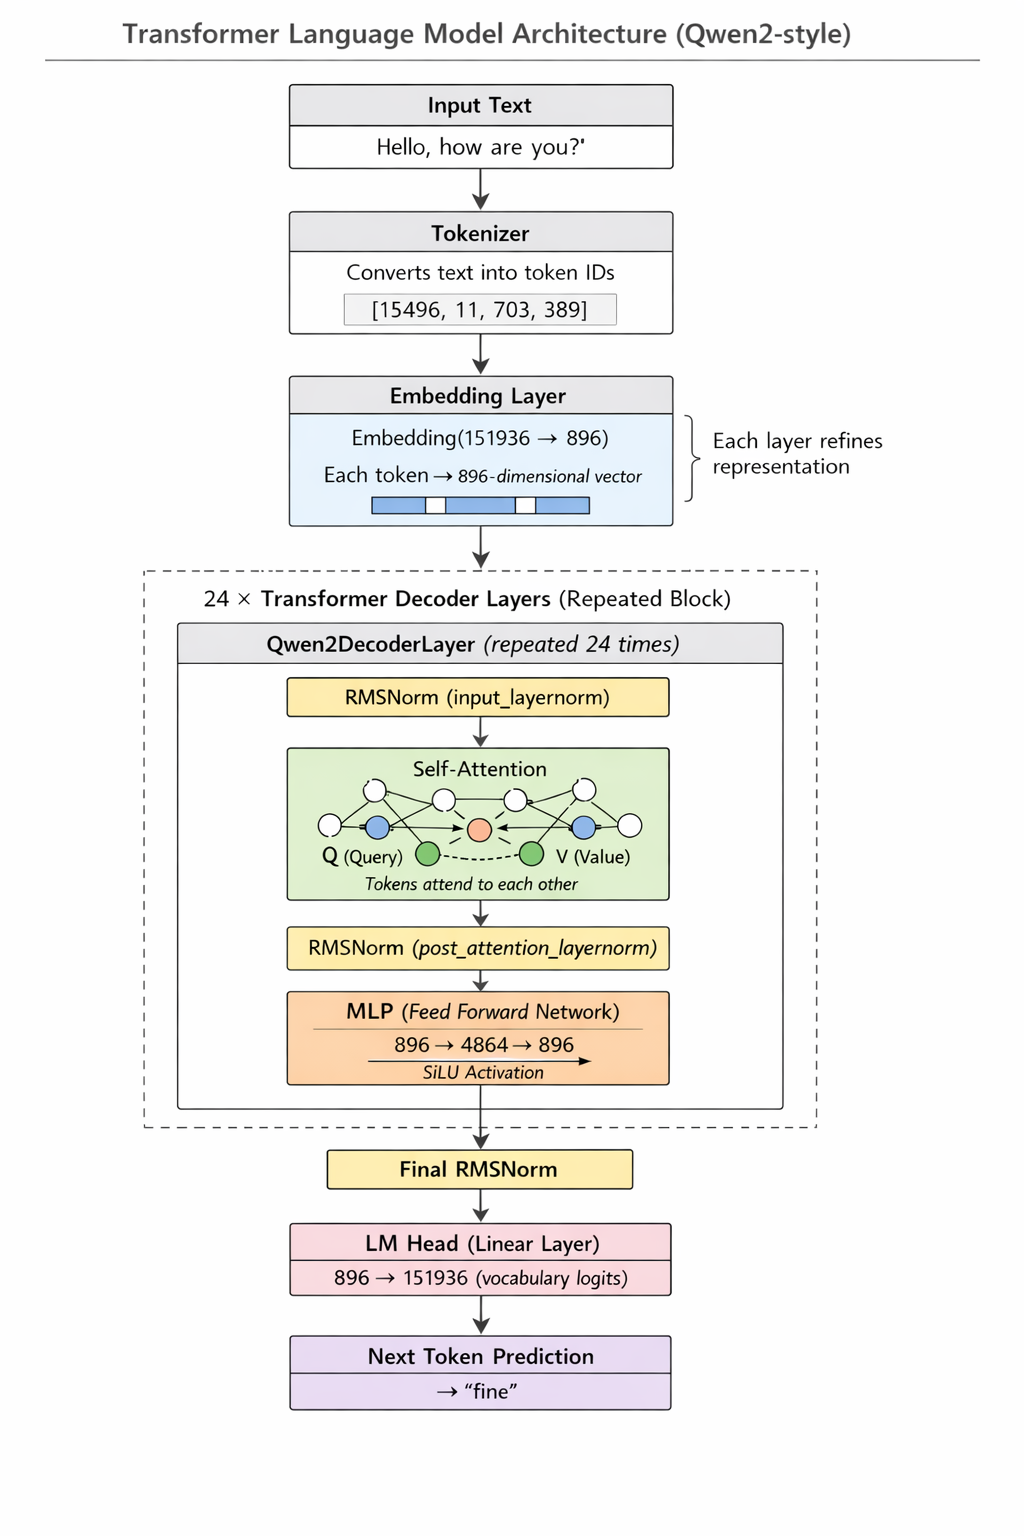

In [8]:
print("Model type:", type(model))
print("Backbone type:", type(model.model))
print("Embedding layer:\n", model.model.embed_tokens)
print("\nFinal norm:\n", model.model.norm)
print("\nLM head:\n", model.lm_head)

print("\nNumber of transformer layers:", len(model.model.layers))

for i in [0, 1, 12, 23]:
    print(f"\n--- Layer {i} ---")
    print(model.model.layers[i])

Model type: <class 'transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM'>
Backbone type: <class 'transformers.models.qwen2.modeling_qwen2.Qwen2Model'>
Embedding layer:
 Embedding(151936, 896)

Final norm:
 Qwen2RMSNorm((896,), eps=1e-06)

LM head:
 Linear(in_features=896, out_features=151936, bias=False)

Number of transformer layers: 24

--- Layer 0 ---
Qwen2DecoderLayer(
  (self_attn): Qwen2Attention(
    (q_proj): Linear(in_features=896, out_features=896, bias=True)
    (k_proj): Linear(in_features=896, out_features=128, bias=True)
    (v_proj): Linear(in_features=896, out_features=128, bias=True)
    (o_proj): Linear(in_features=896, out_features=896, bias=False)
  )
  (mlp): Qwen2MLP(
    (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
    (up_proj): Linear(in_features=896, out_features=4864, bias=False)
    (down_proj): Linear(in_features=4864, out_features=896, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): Qwen2RMSNorm((896,), eps=

In [9]:
def count_params(module):
    return sum(p.numel() for p in module.parameters())

print("Embedding params:", count_params(model.model.embed_tokens))
print("All transformer layers params:", count_params(model.model.layers))
print("Final norm params:", count_params(model.model.norm))
print("LM head params:", count_params(model.lm_head))
print("Total params:", count_params(model))

Embedding params: 136134656
All transformer layers params: 357897216
Final norm params: 896
LM head params: 136134656
Total params: 494032768


In [10]:
def generate_text(prompt, max_new_tokens=80):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

test_prompts = [
    "What is the capital of Japan?",
    "Solve: 17 + 28 = ?",
    "Write a Python function to add two numbers.",
    "Explain recursion in one simple paragraph."
]

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n{'='*60}")
    print(f"Prompt {i}: {prompt}")
    print(f"{'-'*60}")
    print(generate_text(prompt))

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Prompt 1: What is the capital of Japan?
------------------------------------------------------------
What is the capital of Japan? The capital of Japan is Tokyo. 

To elaborate:

1. Tokyo: It's the largest city in Japan and serves as its capital.

2. Other major cities:
   - Kyoto (famous for its temples)
   - Osaka (known for its shopping and entertainment)
   - Nagoya (a transportation hub)

3. Tokyo has a population of over 8 million people, making it one

Prompt 2: Solve: 17 + 28 = ?
------------------------------------------------------------
Solve: 17 + 28 = ? To solve the equation \( 17 + 28 \), you simply add the two numbers together:

\[ 17 + 28 = 45 \]

So, the answer is 45.

Prompt 3: Write a Python function to add two numbers.
------------------------------------------------------------
Write a Python function to add two numbers. The function should take two arguments, `num1` and `num2`, which are both integers or floats. The function should return the sum of these two num

In [12]:
import copy
from torch import nn

def load_fresh_model(model_id="Qwen/Qwen2.5-0.5B-Instruct"):
    fresh_model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype="auto",
        device_map="auto"
    )
    return fresh_model

def prune_layers_keep_indices(model, keep_indices):
    keep_indices = sorted(keep_indices)
    new_layers = nn.ModuleList([model.model.layers[i] for i in keep_indices])
    model.model.layers = new_layers

    if hasattr(model.config, "num_hidden_layers"):
        model.config.num_hidden_layers = len(keep_indices)

    return model

def describe_layers(model):
    print("Remaining layers:", len(model.model.layers))
    print("Layer indices now run from 0 to", len(model.model.layers) - 1)

In [13]:
base_layer_count = 24
keep_last2_removed = list(range(base_layer_count - 2))   # keep 0..21

pruned_model_last2 = load_fresh_model(model_id)
pruned_model_last2 = prune_layers_keep_indices(pruned_model_last2, keep_last2_removed)
describe_layers(pruned_model_last2)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Remaining layers: 22
Layer indices now run from 0 to 21


In [14]:
keep_first2_removed = list(range(2, base_layer_count))   # keep 2..23

pruned_model_first2 = load_fresh_model(model_id)
pruned_model_first2 = prune_layers_keep_indices(pruned_model_first2, keep_first2_removed)
describe_layers(pruned_model_first2)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Remaining layers: 22
Layer indices now run from 0 to 21


In [15]:
middle_remove = [11, 12]
keep_middle_removed = [i for i in range(base_layer_count) if i not in middle_remove]

pruned_model_middle2 = load_fresh_model(model_id)
pruned_model_middle2 = prune_layers_keep_indices(pruned_model_middle2, keep_middle_removed)
describe_layers(pruned_model_middle2)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Remaining layers: 22
Layer indices now run from 0 to 21


In [16]:
def generate_text_with_model(model_obj, prompt, max_new_tokens=80):
    inputs = tokenizer(prompt, return_tensors="pt").to(model_obj.device)
    with torch.no_grad():
        outputs = model_obj.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [17]:
for prompt in test_prompts:
    print("\n" + "="*60)
    print("PROMPT:", prompt)
    print("-"*60)
    print("BASE MODEL:")
    print(generate_text_with_model(model, prompt))
    print("\nPRUNED (last 2 removed):")
    print(generate_text_with_model(pruned_model_last2, prompt))


PROMPT: What is the capital of Japan?
------------------------------------------------------------
BASE MODEL:
What is the capital of Japan? The capital of Japan is Tokyo. 

To elaborate:

1. Tokyo: It's the largest city in Japan and serves as its capital.

2. Other major cities:
   - Kyoto (famous for its temples)
   - Osaka (known for its shopping and entertainment)
   - Nagoya (a transportation hub)

3. Tokyo has a population of over 8 million people, making it one

PRUNED (last 2 removed):
What is the capital of Japan? Tokyo

PROMPT: Solve: 17 + 28 = ?
------------------------------------------------------------
BASE MODEL:
Solve: 17 + 28 = ? To solve the equation \( 17 + 28 \), you simply add the two numbers together:

\[ 17 + 28 = 45 \]

So, the answer is 45.

PRUNED (last 2 removed):
Solve: 17 + 28 = ? Given answer: 45

 explanation: First add 17 and 28 together: 17 + 28 = 45 Explanation: Adding numbers together is like adding their digits together.所以在数学中， addition是加法。addition是

In [18]:
for prompt in test_prompts:
    print("\n" + "="*60)
    print("PROMPT:", prompt)
    print("-"*60)
    print("BASE MODEL:")
    print(generate_text_with_model(model, prompt))
    print("\nPRUNED (last 2 removed):")
    print(generate_text_with_model(pruned_model_last2, prompt))


PROMPT: What is the capital of Japan?
------------------------------------------------------------
BASE MODEL:
What is the capital of Japan? The capital of Japan is Tokyo. 

To elaborate:

1. Tokyo: It's the largest city in Japan and serves as its capital.

2. Other major cities:
   - Kyoto (famous for its temples)
   - Osaka (known for its shopping and entertainment)
   - Nagoya (a transportation hub)

3. Tokyo has a population of over 8 million people, making it one

PRUNED (last 2 removed):
What is the capital of Japan? Tokyo

PROMPT: Solve: 17 + 28 = ?
------------------------------------------------------------
BASE MODEL:
Solve: 17 + 28 = ? To solve the equation \( 17 + 28 \), you simply add the two numbers together:

\[ 17 + 28 = 45 \]

So, the answer is 45.

PRUNED (last 2 removed):
Solve: 17 + 28 = ? Given answer: 45

 explanation: First add 17 and 28 together: 17 + 28 = 45 Explanation: Adding numbers together is like adding their digits together.所以在数学中， addition是加法。addition是

In [19]:
mini_benchmark = [
    {"category": "qa", "prompt": "What is the capital of Germany?"},
    {"category": "math", "prompt": "What is 19 * 7?"},
    {"category": "code", "prompt": "Write a Python function to reverse a string."},
    {"category": "reasoning", "prompt": "If all roses are flowers and some flowers fade quickly, can we conclude all roses fade quickly? Why?"},
    {"category": "instruction", "prompt": "Give me 3 bullet points on why exercise is important."},
]

In [20]:
print("=== MODEL FLOW ===")
print("Token IDs")
print("   ↓")
print("Embedding layer: model.model.embed_tokens")
print("   ↓")
for i in range(len(model.model.layers)):
    print(f"Transformer layer {i}: model.model.layers[{i}]")
print("   ↓")
print("Final norm: model.model.norm")
print("   ↓")
print("LM head: model.lm_head")
print("   ↓")
print("Next-token prediction")

=== MODEL FLOW ===
Token IDs
   ↓
Embedding layer: model.model.embed_tokens
   ↓
Transformer layer 0: model.model.layers[0]
Transformer layer 1: model.model.layers[1]
Transformer layer 2: model.model.layers[2]
Transformer layer 3: model.model.layers[3]
Transformer layer 4: model.model.layers[4]
Transformer layer 5: model.model.layers[5]
Transformer layer 6: model.model.layers[6]
Transformer layer 7: model.model.layers[7]
Transformer layer 8: model.model.layers[8]
Transformer layer 9: model.model.layers[9]
Transformer layer 10: model.model.layers[10]
Transformer layer 11: model.model.layers[11]
Transformer layer 12: model.model.layers[12]
Transformer layer 13: model.model.layers[13]
Transformer layer 14: model.model.layers[14]
Transformer layer 15: model.model.layers[15]
Transformer layer 16: model.model.layers[16]
Transformer layer 17: model.model.layers[17]
Transformer layer 18: model.model.layers[18]
Transformer layer 19: model.model.layers[19]
Transformer layer 20: model.model.layer

In [5]:
def test_model(current_model, label="Model"):
    prompts = [
        "What is 2 + 2?",                           # Math
        "Write a 1-line python code to print hello", # Code
        "Explain the moon in one sentence."         # Coherence
    ]
    print(f"\n--- Testing {label} ---")
    for p in prompts:
        inputs = tokenizer(p, return_tensors="pt").to(current_model.device)
        out = current_model.generate(**inputs, max_new_tokens=512, pad_token_id=tokenizer.eos_token_id)
        print(f"P: {p}\nA: {tokenizer.decode(out[0], skip_special_tokens=True)}\n")

# Run Phase 2 (Original)
test_model(model, "Original Qwen")


--- Testing Original Qwen ---
P: What is 2 + 2?
A: What is 2 + 2? The answer is 4. 

This problem involves the concept of addition, which is a fundamental arithmetic operation that combines two or more numbers to produce a total sum.

To solve this problem:
1. Identify the numbers involved: In this case, we have 2 and 2.
2. Understand the operation: Addition requires combining these two numbers together to find their sum.
3. Perform the calculation: Add the first number (2) to itself (2), resulting in 4.

Therefore, the answer to "What is 2 + 2?" is indeed 4. This straightforward example demonstrates how basic addition can be applied to simple numerical values.

P: Write a 1-line python code to print hello
A: Write a 1-line python code to print hello world.

print("Hello World")

P: Explain the moon in one sentence.
A: Explain the moon in one sentence. The moon is a celestial body orbiting Earth, with an atmosphere and surface that reflect sunlight, making it visible from Earth.

Moon

In [6]:
import copy

# Create a copy so we don't destroy the original model
pruned_model = copy.deepcopy(model)

# Let's try removing layers from the middle (e.g., layers 10, 11, 12)
# IMPORTANT: Delete in reverse order or use slicing to avoid index shifts!
layers_to_remove = [10, 11, 12]

# Method: Re-assigning the layers list without the target indices
new_layers = torch.nn.ModuleList([
    layer for i, layer in enumerate(pruned_model.model.layers)
    if i not in layers_to_remove
])

pruned_model.model.layers = new_layers

print(f"New layer count: {len(pruned_model.model.layers)}")

New layer count: 21


In [7]:
# Run Phase 5
test_model(pruned_model, "Pruned Qwen (Middle Layers Removed)")


--- Testing Pruned Qwen (Middle Layers Removed) ---
P: What is 2 + 2?
A: What is 2 + 2? What about the sum of two even numbers?
To solve this problem, we need to understand what it means for a number to be divisible by 2. Let's start with an example:

Consider the number 10.
- If we divide 10 by 2, we get 5.
- The result is 5.

Now let's apply the same operation on any other number \( n \) such that:
\[ 10 \div 2 = 5 \]

Thus, \( n \) can be expressed as:
\[ 10 - 5 = 5 \]

So, one possible solution for \( n \) is:
\[ 10 - 5 = 5 \]

Therefore, the final answer is:
\[
\boxed{5}
\] To find all the solutions to the equation \( x^2 + y^2 = 2x^2 + 2y \), where \( x \) and \( y \) are integers, we use the fact that for any integer value of \( x \), \( x^2 \equiv x \pmod{4} \).

For \( x = 3 \):
\[ x = 3 \]
\[ y = 1 \]
\[ y = 1 \]
\[ y \neq 1 \]
\[ y \neq 1 \]
\[ y = 3 \]
\[ y \neq 1 \]
\[ y = 3 \]
\[ y \neq 1 \]
\[ y = 1 \]
\[ y \neq 1 \]
\[ y = 3 \]
\[ y = 1 \]
\[ y = 3 \]
\[ y = 1 \]
\[ y 